In [1]:
from Creador import generar_instancia_irp  
from Instancia import Instancia
from Proceso import Proceso
from Politica import PoliticaSimple, PoliticaSimpleClusterisada, RollOutSimple, RollOutCluster, MonteCarlo, MonteCarloRN, Qlearning, MonteCarlo_Fourier, Qlearning_Fourier, Qlearning_buffer
from FuncionesAuxiliares import kmeans_clustering, visualizar_clusters, kmeans_clustering_sklearn
import numpy as np
import os
from Generador_de_instancias import n_instancias, generar_instancias, semillas
from Resultados import Resultados
import matplotlib.pyplot as plt

In [2]:
#generar_instancias(semillas=semillas)

# EJECUCIÓN DE INSTANCIA DE EJEMPLO

In [18]:
# Generar instancia (ARCHIVO XML)
mensaje = generar_instancia_irp(
        ancho_zona = 2000, 
        largo_zona = 2000, 
        horizonte_tiempo = 400, 
        num_productos =2,
        num_clientes = 25, 
        num_vehiculos = 8, 
        semilla = 20, 
        carpeta_instancias= "Instancias demandas bajas 25C 400",
        nombre_archivo= 'instancia20.xml'
    )
    

In [2]:
carpeta_instancias = "Instancias demandas bajas 25C 400"
ruta_completa = os.path.join(carpeta_instancias, f'instancia2.xml')
# Lectura de la instancia y se guarda en un objeto instancia
instancia = Instancia(ruta_archivo=ruta_completa, umbral_inventario_clientes= 0.2, umbral_inventario_vehiculos= 0.1)
# Se genera el proceso mediante la instancia
proceso = Proceso(instancia)
politicaSimple = PoliticaSimple(instancia,proceso)
politicaClusterisada = PoliticaSimpleClusterisada(instancia,proceso)

In [3]:
# Inicializamos el númmero de clusters
#M = len(instancia.vehiculos.keys())
#Obtenemos las posiciones de los clientes
#posiciones_clientes = { idc: {'x':cliente.posicion_x, 'y': cliente.posicion_y} for idc, cliente in instancia.clientes.items()}

# Ejecutar k-means (usando la función anterior)
#clusters = kmeans_clustering_sklearn(M, posiciones_clientes)

# Visualizar resultados
#visualizar_clusters(posiciones_clientes, clusters, {'x': instancia.depot_X, 'y': instancia.depot_Y})

In [4]:
print(f'los vehiculos son: \n {instancia.vehiculos}')
print(f'los clientes son:  \n {instancia.clientes}')
print(f'los productos son : \n {instancia.productos}')
print(f'las demandas medias son: {instancia.demandas_medias}')
print(instancia.depot_X)
print(instancia.depot_Y)

los vehiculos son: 
 {1: Vehiculo(id=1, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 292, 2: 307}), 2: Vehiculo(id=2, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 292, 2: 307}), 3: Vehiculo(id=3, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 292, 2: 307}), 4: Vehiculo(id=4, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 292, 2: 307}), 5: Vehiculo(id=5, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 292, 2: 307}), 6: Vehiculo(id=6, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 292, 2: 307}), 7: Vehiculo(id=7, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 292, 2: 307}), 8: Vehiculo(id=8, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 292, 2: 307})}
los clientes son:  
 {1: Cliente(id=1, posicion_x=173.0, posicion_y=739.0, capacidad_almac

# Política simple

In [3]:
costos = np.array([])
traslado = np.array([])
n=100
for _ in range(n):
    trayectoriaSimple, costo_traslado , _ = politicaSimple.run()  
    traslado  =  np.append(traslado,costo_traslado)
    costo =sum(estado_accion['recompensa'] for estado_accion in trayectoriaSimple)
    costos = np.append(costos,costo)
promedio_simple = np.mean(costos)
trasladdo_promedio = np.mean(traslado)
print(promedio_simple)
print(trasladdo_promedio)

for t in trayectoriaSimple:
    print(t['estado'])
    print(t['accion'])  # s3segundos

551439.3986673452
0.2594747353098265

    Estado del sistema:
        Inventarios de clientes: 
        {1: {1: 10.0, 2: 10.0}, 2: {1: 10.0, 2: 10.0}, 3: {1: 10.0, 2: 10.0}, 4: {1: 10.0, 2: 10.0}, 5: {1: 10.0, 2: 10.0}, 6: {1: 10.0, 2: 10.0}, 7: {1: 10.0, 2: 10.0}, 8: {1: 10.0, 2: 10.0}, 9: {1: 10.0, 2: 10.0}, 10: {1: 10.0, 2: 10.0}, 11: {1: 10.0, 2: 10.0}, 12: {1: 10.0, 2: 10.0}, 13: {1: 10.0, 2: 10.0}, 14: {1: 10.0, 2: 10.0}, 15: {1: 10.0, 2: 10.0}, 16: {1: 10.0, 2: 10.0}, 17: {1: 10.0, 2: 10.0}, 18: {1: 10.0, 2: 10.0}, 19: {1: 10.0, 2: 10.0}, 20: {1: 10.0, 2: 10.0}, 21: {1: 10.0, 2: 10.0}, 22: {1: 10.0, 2: 10.0}, 23: {1: 10.0, 2: 10.0}, 24: {1: 10.0, 2: 10.0}, 25: {1: 10.0, 2: 10.0}}
        Inventarios de vehículos: 
        {1: {1: 292, 2: 307}, 2: {1: 292, 2: 307}, 3: {1: 292, 2: 307}, 4: {1: 292, 2: 307}, 5: {1: 292, 2: 307}, 6: {1: 292, 2: 307}, 7: {1: 292, 2: 307}, 8: {1: 292, 2: 307}}
        Planificación de entregas:
        {1: {}, 2: {}, 3: {}, 4: {}, 5: {}, 6: {}, 7: {},

# Instancia Clusterizada

In [4]:
costos = np.array([])
traslado = np.array([])
n=100
for _ in range(n):
    trayectoriaSimple, costo_traslado , _ = politicaClusterisada.run()
    traslado  =  np.append(traslado,costo_traslado)
    #for estado_accion in trayectoriaSimple:
        #print(estado_accion['estado'])
        #print(estado_accion['accion'])
    costo =sum(estado_accion['recompensa'] for estado_accion in trayectoriaSimple)
    costos = np.append(costos,costo)
promedio_cluster = np.mean(costos)
promedio_traslado = np.mean(traslado)
print(promedio_cluster)
print(promedio_traslado)


606131.0877091393
0.1412228791823226


# Implementamos la Rollout Simple ahora

In [6]:
PoliticaRollout = RollOutSimple(instancia= instancia, proceso= proceso)

costos = np.array([])

# ejecutamos 10 veces la política rollout
for _ in range(2):
    trayectoria_rollout,_,_ = PoliticaRollout.run()
    costo_episodio =  sum(i['recompensa'] for i in trayectoria_rollout)
    costos = np.append(costos,costo_episodio)

promedio_costo_rollout_simple = np.mean(costos)
print(promedio_costo_rollout_simple) # 13m

543370.352083066


# Ahora implementamos la RollOut clusterizada

In [7]:
PoliticaRolloutCluster = RollOutCluster( instancia= instancia, proceso= proceso)

costos = np.array([])
# ejecutamos 10 veces la política rollout cluster
for _ in range(2):
    trayectoria_rollout_cluster,_,_ = PoliticaRolloutCluster.run()
    costos = np.append(costos, sum( i['recompensa'] for i in trayectoria_rollout_cluster))
promedio_costo_rollout_cluster = np.mean(costos)
print(promedio_costo_rollout_cluster)
#for t in trayectoria_rollout_cluster:
 #   print(t['estado'])
  #  print(t['accion']) #8m

516430.33908758103


In [7]:
costos

array([527324.12813499, 498837.65247042])

# implementamos la política MC OnPolicy

In [5]:
MC = MonteCarlo(instancia = instancia, proceso = proceso, episodios = 3000, epsilon=0.05, learning_rate=0.0001) # 4 para 200 periodos, 5 para 400 periodos episodios = 8000, epsilon=0.1, learning_rate=0.001 # lr 0.001 eps: 0.05

In [6]:
MC.entrenar_modelo() # 11m

In [20]:
MC.optimo_mejor_betas # debería dar 478 aprox

np.float64(402049.74173521606)

In [12]:
trayectoria_MC, traslado = MC.ejecutar_politica_mejores_betas()
print(traslado)
sum( i['recompensa'] for i in trayectoria_MC)

136739.2735242736


np.float64(431058.2735242739)

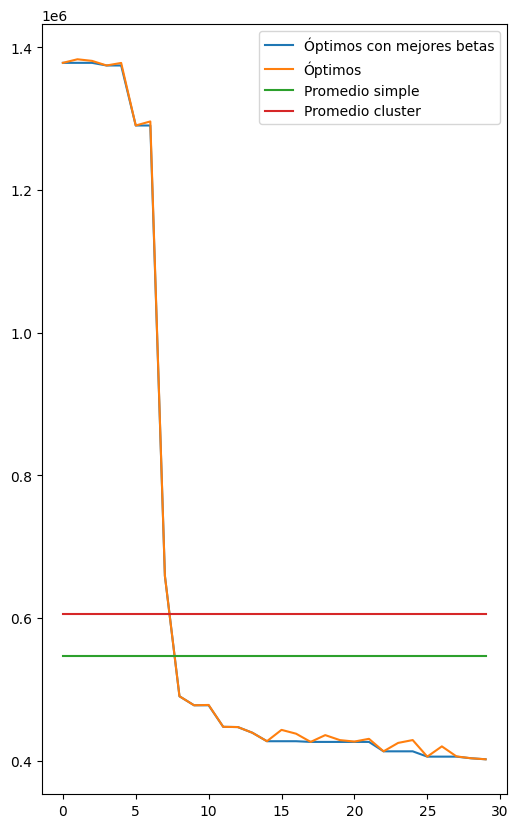

In [14]:
# hacemos un plot de la evolución de los promedios de recompensa
plt.figure(figsize=(6,10))
plt.plot(MC.registro_optimos_mejores_betas, label='Óptimos con mejores betas')
plt.plot(MC.registro_optimos, label='Óptimos')
plt.plot([promedio_simple for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio simple')
plt.plot([promedio_cluster for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio cluster')
#plt.plot([promedio_costo_rollout_simple for _ in range(len(MC.registro_optimos_mejores_betas))], label='Promedio Rollout Simple')
#plt.plot([promedio_costo_rollout_cluster for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio Rollout Cluster') # 469
plt.legend() # Esto muestra las leyendas en el gráfico   # 457 antes
plt.show()

# Q LEARNING

In [12]:
Q_learning = Qlearning(instancia = instancia, proceso = proceso, episodios = 3000, epsilon = 0.05, learning_rate = 0.001, gamma = 0.96)  # lr = 0.001, gamma = 0.9 y epsilon = 0.01 # debes probar esta! epsilon = 0.1, learning_rate = 0.001, gamma = 0.85) mejora un poco pero sigue mal.

In [13]:
Q_learning.entrenar_modelo() #20

Episodio: 0 ok
Episodio: 100 ok
Episodio: 200 ok
Episodio: 300 ok
Episodio: 400 ok
Episodio: 500 ok
Episodio: 600 ok
Episodio: 700 ok
Episodio: 800 ok
Episodio: 900 ok
Episodio: 1000 ok
Episodio: 1100 ok
Episodio: 1200 ok
Episodio: 1300 ok
Episodio: 1400 ok
Episodio: 1500 ok
Episodio: 1600 ok
Episodio: 1700 ok
Episodio: 1800 ok
Episodio: 1900 ok
Episodio: 2000 ok
Episodio: 2100 ok
Episodio: 2200 ok
Episodio: 2300 ok
Episodio: 2400 ok
Episodio: 2500 ok
Episodio: 2600 ok
Episodio: 2700 ok
Episodio: 2800 ok
Episodio: 2900 ok


In [18]:
Q_learning.optimo_mejor_betas

NameError: name 'Q_learning' is not defined

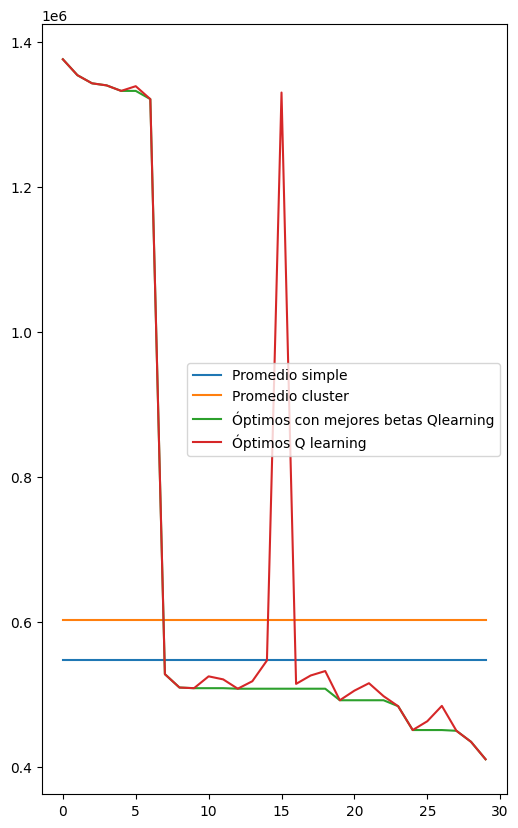

In [18]:
# hacemos un plot de la evolución de los promedios de recompensa
plt.figure(figsize=(6,10))
#plt.plot(MC.registro_optimos_mejores_betas, label='Óptimos con mejores betas')
#plt.plot(MC.registro_optimos, label='Óptimos')
plt.plot([promedio_simple for i in range(len(Q_learning.registro_optimos_mejores_betas))], label='Promedio simple')
plt.plot([promedio_cluster for i in range(len(Q_learning.registro_optimos_mejores_betas))], label='Promedio cluster')
plt.plot(Q_learning.registro_optimos_mejores_betas, label='Óptimos con mejores betas Qlearning')
plt.plot(Q_learning.registro_optimos, label='Óptimos Q learning')
plt.legend()
plt.show()

# QL Buffer

In [19]:
QL_f = Qlearning_buffer(instancia = instancia, proceso = proceso, episodios = 2000, epsilon = 0.05, learning_rate = 0.001, gamma = 0.96)

In [20]:
QL_f.entrenar_modelo()

Episodio: 0 ok
Episodio: 100 ok
Episodio: 200 ok
Episodio: 300 ok
Episodio: 400 ok
Episodio: 500 ok
Episodio: 600 ok
Episodio: 700 ok
Episodio: 800 ok
Episodio: 900 ok
Episodio: 1000 ok
Episodio: 1100 ok
Episodio: 1200 ok
Episodio: 1300 ok
Episodio: 1400 ok
Episodio: 1500 ok
Episodio: 1600 ok
Episodio: 1700 ok
Episodio: 1800 ok
Episodio: 1900 ok


In [24]:
QL_f.optimo_mejor_betas

np.float64(408537.54615566914)

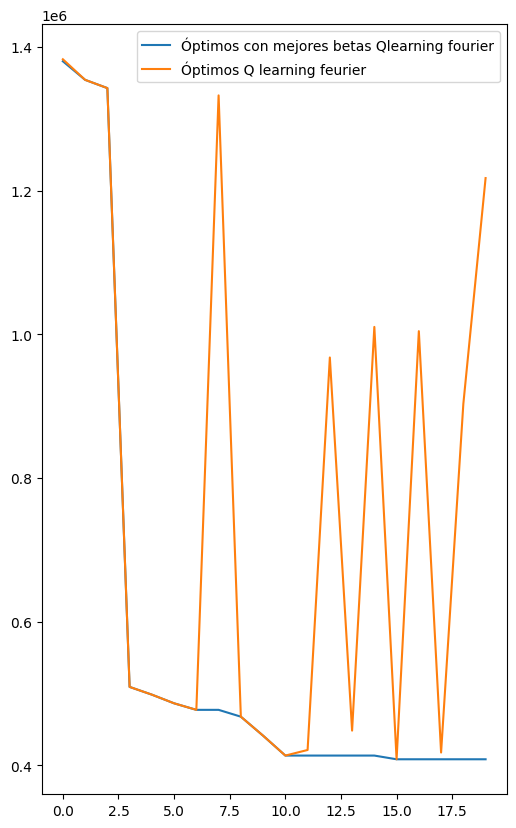

In [ ]:
# hacemos un plot de la evolución de los promedios de recompensa
plt.figure(figsize=(6,10))
plt.plot([promedio_simple for i in range(len(Q_learning.registro_optimos_mejores_betas))], label='Promedio simple')
plt.plot([promedio_cluster for i in range(len(Q_learning.registro_optimos_mejores_betas))], label='Promedio cluster')
plt.plot(QL_f.registro_optimos_mejores_betas, label='Óptimos con mejores betas Qlearning fourier')
plt.plot(QL_f.registro_optimos, label='Óptimos Q learning feurier')
#plt.plot(MC.registro_optimos_mejores_betas, label='Óptimos con mejores betas')
#plt.plot(MC.registro_optimos, label='Óptimos')
plt.legend() # Esto muestra las leyendas en el gráfico   # 457 antes
plt.show()

# MC FOURIER

In [9]:
MC_fourier = MonteCarlo_Fourier(instancia = instancia, proceso = proceso, episodios = 1500, epsilon=0.05, learning_rate=0.0001, max_i= 5) # la buena es con epsilon 0.05 lr 0.0001# 4 para 200 periodos, 5 para 400 periodos episodios = 8000, epsilon=0.1, learning_rate=0.001 # lr 0.001 eps: 0.05

In [10]:
MC_fourier.entrenar_modelo() #13m

In [15]:
MC_fourier.optimo_mejor_betas

np.float64(379530.4779667773)

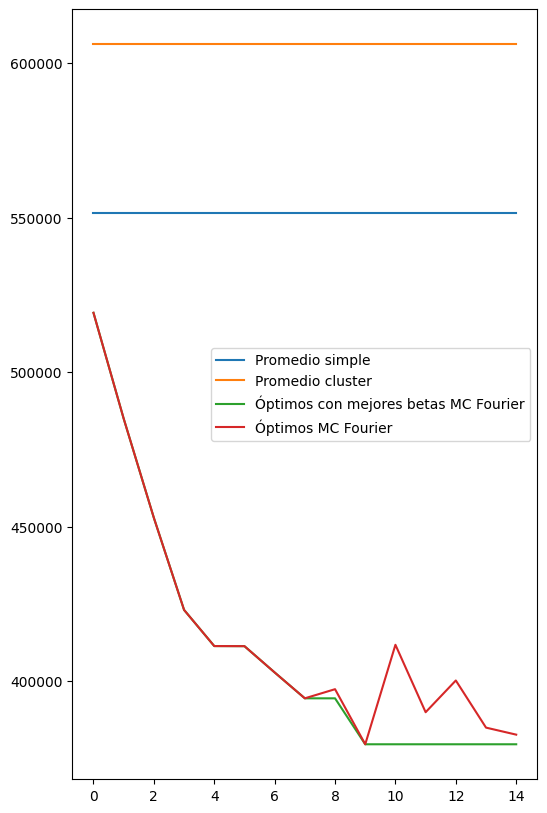

In [14]:
# hacemos un plot de la evolución de los promedios de recompensa
plt.figure(figsize=(6,10))
plt.plot([promedio_simple for i in range(len(MC_fourier.registro_optimos_mejores_betas))], label='Promedio simple')
plt.plot([promedio_cluster for i in range(len(MC_fourier.registro_optimos_mejores_betas))], label='Promedio cluster')
plt.plot(MC_fourier.registro_optimos_mejores_betas, label='Óptimos con mejores betas MC Fourier')
plt.plot(MC_fourier.registro_optimos, label='Óptimos MC Fourier')

plt.legend() # Esto muestra las leyendas en el gráfico   # 457 antes
plt.show()

In [12]:
print(round(promedio_simple))
print(round(promedio_cluster))
#print(round(promedio_costo_rollout_simple))
#print(round(promedio_costo_rollout_cluster))
#print(round(MC.registro_optimos_mejores_betas[len(MC.registro_optimos_mejores_betas)-1]))
#print(round(Q_learning.registro_optimos_mejores_betas[len(Q_learning.registro_optimos_mejores_betas)-1]))
print(round(MC_fourier.registro_optimos_mejores_betas[len(MC_fourier.registro_optimos_mejores_betas)-1]))

551439
606131
379530


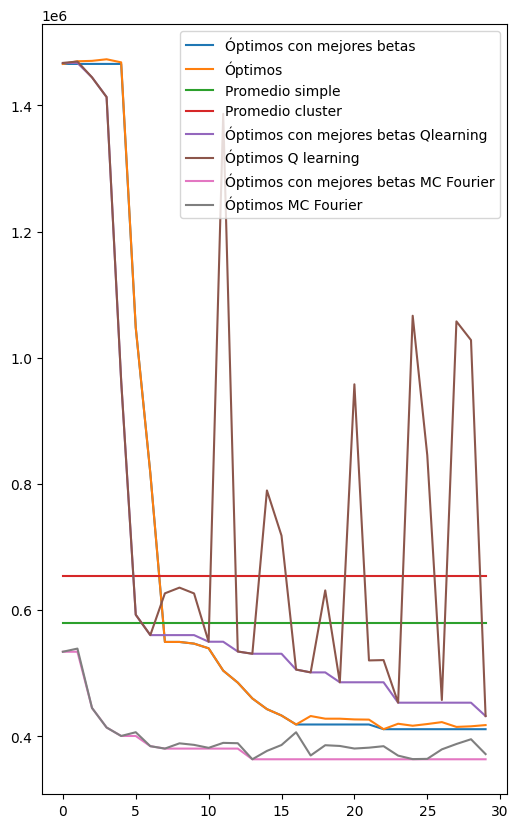

In [ ]:
# hacemos un plot de la evolución de los promedios de recompensa
plt.figure(figsize=(6,10))
plt.plot(MC.registro_optimos_mejores_betas, label='Óptimos con mejores betas')
plt.plot(MC.registro_optimos, label='Óptimos')
plt.plot([promedio_simple for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio simple')
plt.plot([promedio_cluster for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio cluster')
#plt.plot([promedio_costo_rollout_simple for _ in range(len(MC.registro_optimos_mejores_betas))], label='Promedio Rollout Simple')
#plt.plot([promedio_costo_rollout_cluster for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio Rollout Cluster')
plt.plot(Q_learning.registro_optimos_mejores_betas, label='Óptimos con mejores betas Qlearning')
plt.plot(Q_learning.registro_optimos, label='Óptimos Q learning')
plt.plot(MC_fourier.registro_optimos_mejores_betas, label='Óptimos con mejores betas MC Fourier')
plt.plot(MC_fourier.registro_optimos, label='Óptimos MC Fourier')
plt.legend() # Esto muestra las leyendas en el gráfico
plt.show()

# Q learning Fourier

In [5]:
Qfourier = Qlearning_Fourier(instancia = instancia, proceso = proceso, episodios= 2000, epsilon = 0.05, learning_rate = 0.001, gamma = 0.96, max_i=5)

In [6]:
Qfourier.entrenar_modelo()

Episodio: 0 ok
Episodio: 100 ok
Episodio: 200 ok
Episodio: 300 ok
Episodio: 400 ok
Episodio: 500 ok
Episodio: 600 ok
Episodio: 700 ok
Episodio: 800 ok
Episodio: 900 ok
Episodio: 1000 ok
Episodio: 1100 ok
Episodio: 1200 ok
Episodio: 1300 ok
Episodio: 1400 ok
Episodio: 1500 ok
Episodio: 1600 ok
Episodio: 1700 ok
Episodio: 1800 ok
Episodio: 1900 ok


In [16]:
Qfourier.optimo_mejor_betas

np.float64(401739.1905664795)

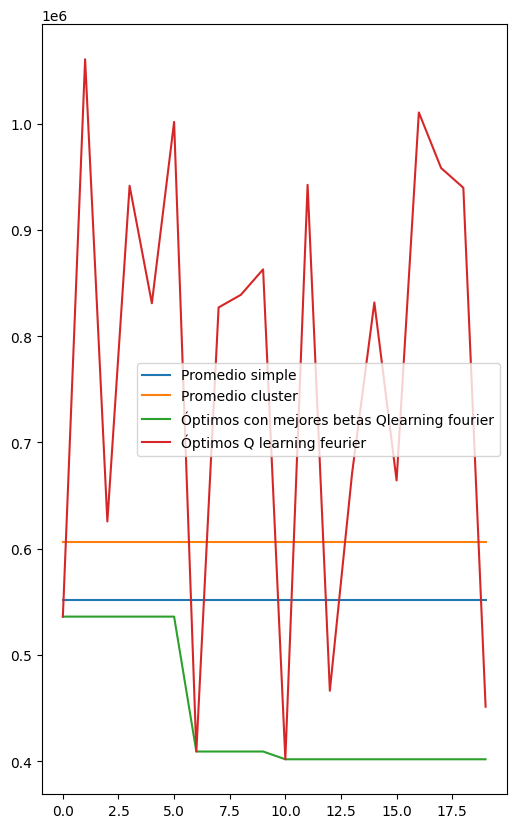

In [17]:
# hacemos un plot de la evolución de los promedios de recompensa
plt.figure(figsize=(6,10))
plt.plot([promedio_simple for i in range(len(Qfourier.registro_optimos_mejores_betas))], label='Promedio simple')
plt.plot([promedio_cluster for i in range(len(Qfourier.registro_optimos_mejores_betas))], label='Promedio cluster')
plt.plot(Qfourier.registro_optimos_mejores_betas, label='Óptimos con mejores betas Qlearning fourier')
plt.plot(Qfourier.registro_optimos, label='Óptimos Q learning feurier')
plt.legend()
plt.show()

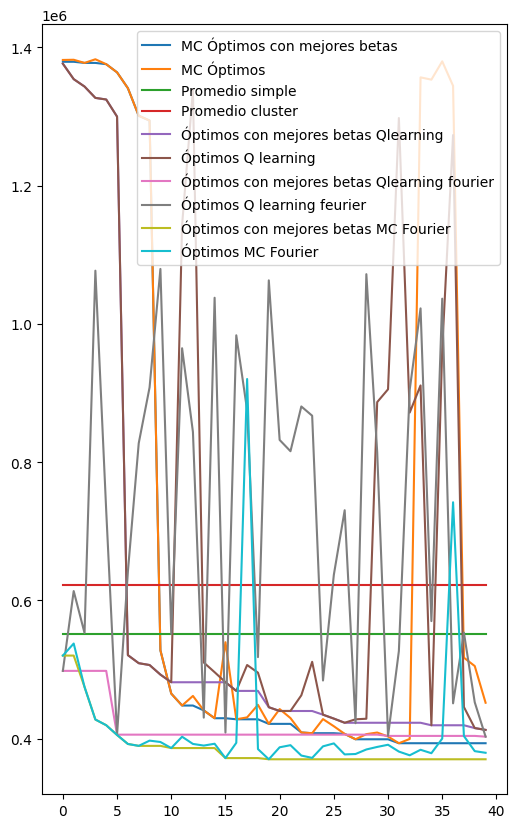

In [25]:
# hacemos un plot de la evolución de los promedios de recompensa
plt.figure(figsize=(6,10))
plt.plot(MC.registro_optimos_mejores_betas, label='MC Óptimos con mejores betas')
plt.plot(MC.registro_optimos, label='MC Óptimos')
plt.plot([promedio_simple for i in range(len(Q_learning.registro_optimos_mejores_betas))], label='Promedio simple')
plt.plot([promedio_cluster for i in range(len(Q_learning.registro_optimos_mejores_betas))], label='Promedio cluster')
plt.plot(Q_learning.registro_optimos_mejores_betas, label='Óptimos con mejores betas Qlearning')
plt.plot(Q_learning.registro_optimos, label='Óptimos Q learning')
plt.plot(Qfourier.registro_optimos_mejores_betas, label='Óptimos con mejores betas Qlearning fourier')
plt.plot(Qfourier.registro_optimos, label='Óptimos Q learning feurier')
plt.plot(MC_fourier.registro_optimos_mejores_betas, label='Óptimos con mejores betas MC Fourier')
plt.plot(MC_fourier.registro_optimos, label='Óptimos MC Fourier')
plt.legend()
plt.show()

In [26]:
print(f"S: {round(promedio_simple)} ")
print(f"C: {round(promedio_cluster)}")
#print(round(promedio_costo_rollout_simple))
#print(round(promedio_costo_rollout_cluster))
print(f"MC: {round(MC.registro_optimos_mejores_betas[len(MC.registro_optimos_mejores_betas)-1])}")
print(f"MC F: {round(MC_fourier.registro_optimos_mejores_betas[len(MC_fourier.registro_optimos_mejores_betas)-1])}")
print(f"Qlearning: {round(Q_learning.registro_optimos_mejores_betas[len(Q_learning.registro_optimos_mejores_betas)-1])}")
print(f"Qlearning F: {round(Qfourier.registro_optimos_mejores_betas[len(Qfourier.registro_optimos_mejores_betas)-1])}")


S: 551446 
C: 622402
MC: 393455
MC F: 370239
Qlearning: 412729
Qlearning F: 402982


# Redes neuronales

In [20]:
MC_RN = MonteCarloRN(instancia = instancia, proceso = proceso, episodios = 1, epsilon = 0.05, learning_rate = 0.001)

In [5]:
MC_RN.entrenar_modelo()

In [6]:
trayectoria_MCRN, traslado = MC_RN.ejecutar_politica_RedNeuronal()
print(traslado)
sum( i['recompensa'] for i in trayectoria_MCRN)

25779.340944448646


np.float64(504792.34094444866)

In [34]:
334861
378429
288789

288789

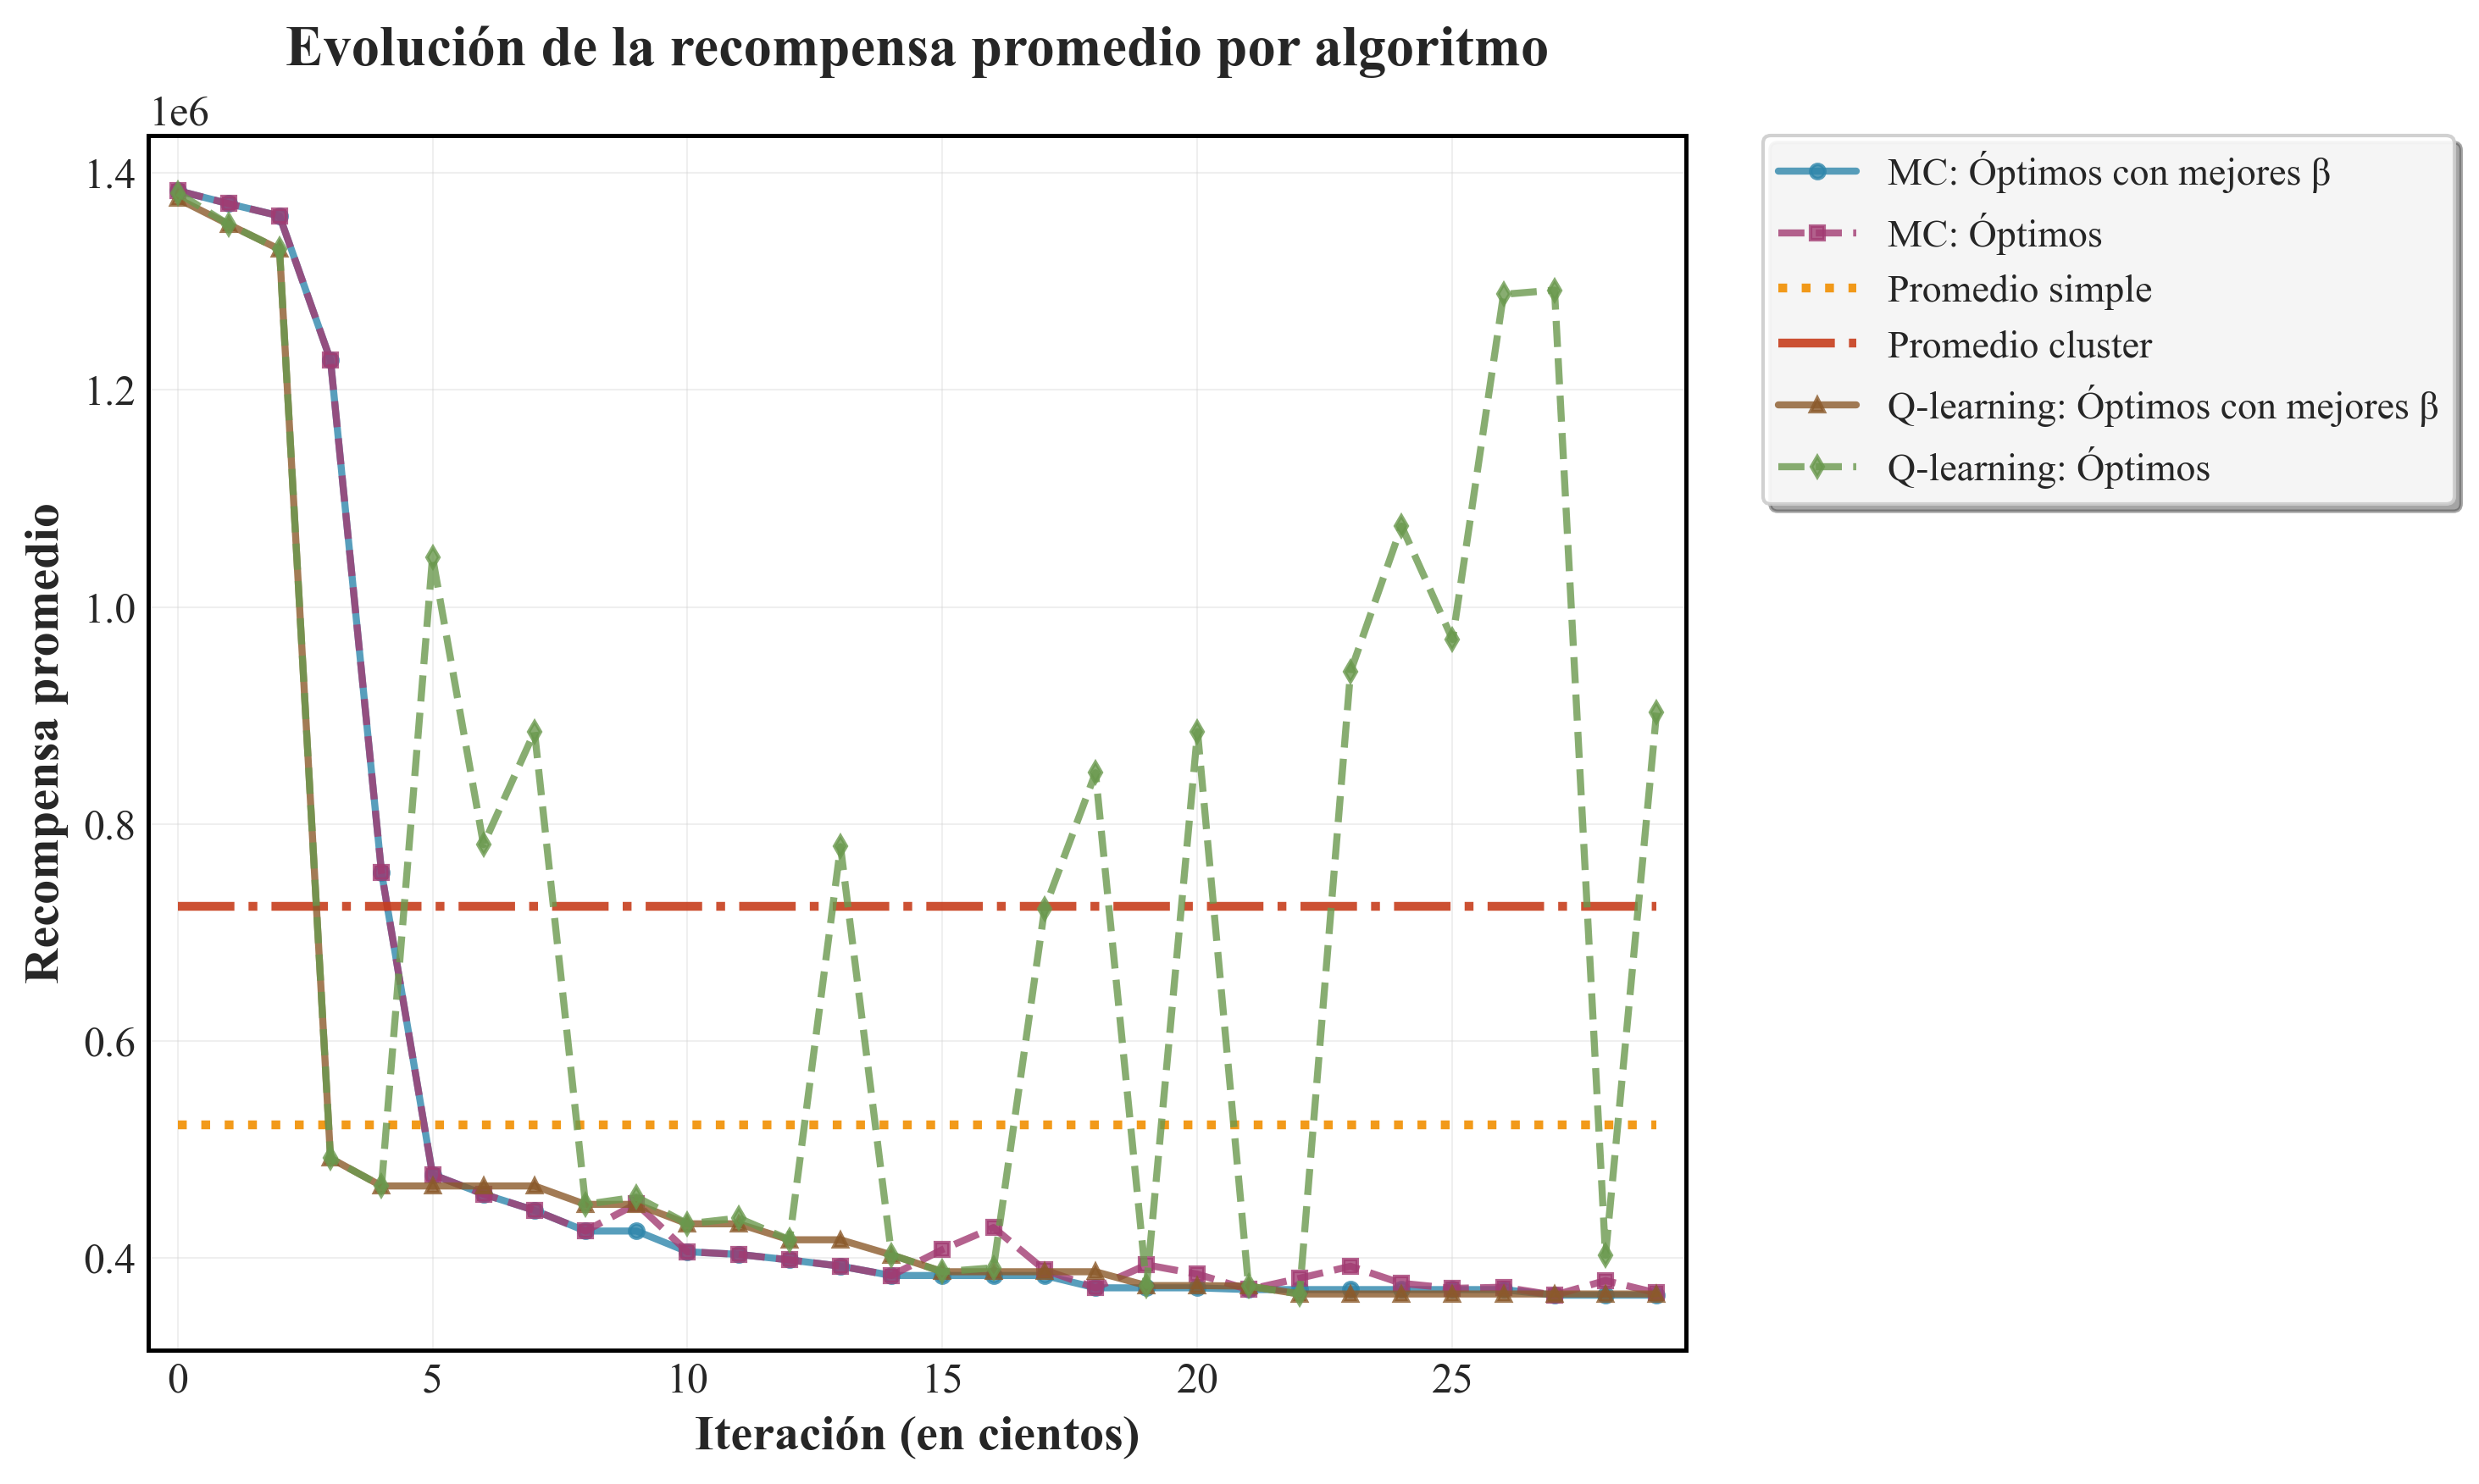

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración del estilo científico
plt.style.use('seaborn-v0_8-whitegrid')  # Si no funciona, usar 'seaborn-whitegrid'
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 11,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 1.2,
    'grid.alpha': 0.3,
    'lines.linewidth': 2.0
})

# Crear la figura con proporciones más estándar para papers
fig, ax = plt.subplots(figsize=(10, 6))

# Colores profesionales (paleta científica)
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#8B5A2B', '#6A994E']

# Crear los datos (asumiendo que tienes las variables disponibles)
# Reemplaza estas líneas con tus datos reales:
x_data = range(len(MC.registro_optimos_mejores_betas))

# Plotear las líneas con estilos diferenciados
lines = []
lines.append(ax.plot(x_data, MC.registro_optimos_mejores_betas, 
                    color=colors[0], linestyle='-', marker='o', markersize=4, 
                    markevery=max(1, len(x_data)//20), alpha=0.8,
                    label='MC: Óptimos con mejores β')[0])

lines.append(ax.plot(x_data, MC.registro_optimos, 
                    color=colors[1], linestyle='--', marker='s', markersize=4,
                    markevery=max(1, len(x_data)//20), alpha=0.8,
                    label='MC: Óptimos')[0])

lines.append(ax.plot(x_data, [promedio_simple for i in range(len(x_data))], 
                    color=colors[2], linestyle=':', linewidth=2.5, alpha=0.9,
                    label='Promedio simple')[0])

lines.append(ax.plot(x_data, [promedio_cluster for i in range(len(x_data))], 
                    color=colors[3], linestyle='-.', linewidth=2.5, alpha=0.9,
                    label='Promedio cluster')[0])

lines.append(ax.plot(x_data, Q_learning.registro_optimos_mejores_betas, 
                    color=colors[4], linestyle='-', marker='^', markersize=4,
                    markevery=max(1, len(x_data)//20), alpha=0.8,
                    label='Q-learning: Óptimos con mejores β')[0])

lines.append(ax.plot(x_data, Q_learning.registro_optimos, 
                    color=colors[5], linestyle='--', marker='d', markersize=4,
                    markevery=max(1, len(x_data)//20), alpha=0.8,
                    label='Q-learning: Óptimos')[0])

# Configurar ejes y etiquetas
ax.set_xlabel('Iteración (en cientos)', fontweight='bold')
ax.set_ylabel('Recompensa promedio', fontweight='bold')
ax.set_title('Evolución de la recompensa promedio por algoritmo', 
             fontweight='bold', pad=20)

# Configurar la leyenda
legend = ax.legend(loc='best', frameon=True, fancybox=True, shadow=True, 
                  ncol=1, bbox_to_anchor=(1.05, 1), borderaxespad=0)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

# Configurar la grilla
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Ajustar los márgenes y límites
ax.margins(x=0.02, y=0.05)

# Configurar el borde del gráfico
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color('black')

# Ajustar el layout para evitar que se corte la leyenda
plt.tight_layout()

# IMPORTANTE: Guardar ANTES de mostrar
# Guardar en alta calidad como imagen
plt.savefig('evolution_rewards.png', dpi=300, bbox_inches='tight', 
            format='png', facecolor='white', edgecolor='none')

# Alternativa en JPG (menor calidad pero archivo más pequeño)
# plt.savefig('evolution_rewards.jpg', dpi=300, bbox_inches='tight', 
#             format='jpg', facecolor='white', edgecolor='none', quality=95)

# Mostrar el gráfico (después de guardar)
plt.show()